<a href="https://colab.research.google.com/github/Nikhilth123/oib-sip/blob/main/emailspam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [ ]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df.shape

(5572, 5)

In [ ]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [ ]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [ ]:
df = df[['v1','v2']]

In [ ]:
df.columns = ['label','message']

In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


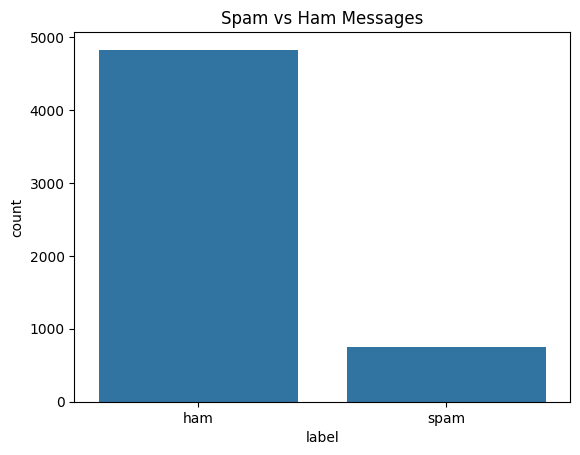

In [ ]:
sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Messages")
plt.show()

In [ ]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [ ]:
X = df['message']

In [ ]:
y = df['label']

In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
X = vectorizer.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9623318385650225


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



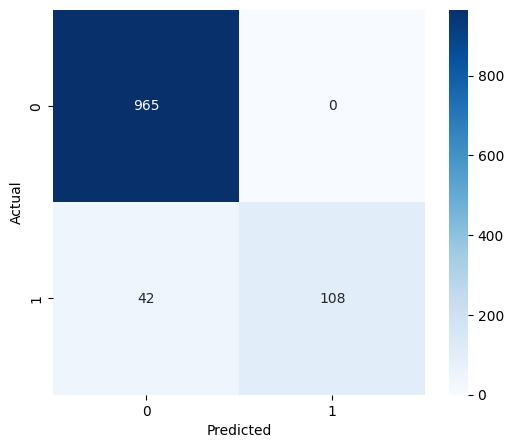

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
email = [
    "Congratulations! You have won a free iPhone. Click here now."
]

In [ ]:
email_vector = vectorizer.transform(email)

In [ ]:
prediction = model.predict(email_vector)

print(prediction)

[0]


In [ ]:
if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Not Spam


In [ ]:
email = ["Win ₹50000 now. Claim your reward immediately."]

In [ ]:
email_vector = vectorizer.transform(email)

In [ ]:
prediction = model.predict(email_vector)

print(prediction)

[0]


In [ ]:
email = ["Hi Nikhil, are you free for the meeting tomorrow?"]

In [ ]:
email_vector = vectorizer.transform(email)

In [ ]:
prediction = model.predict(email_vector)

print(prediction)

[0]


In [ ]:
email = ["Hi Nikhil, can we meet tomorrow to discuss the project?"]

email_vector = vectorizer.transform(email)

prediction = model.predict(email_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Not Spam


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9623318385650225


In [ ]:
print(df.head())
print(df.columns)

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
Index(['label', 'message'], dtype='object')
